In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(" Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(10)

 Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
# 1. Basic info
print("=== DATASET INFO ===")
df.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# 2. Statistical summary
print("\n=== STATISTICS ===")
df.describe(include='all')



=== STATISTICS ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
# 3. Missing values — with percentage
print("\n=== MISSING VALUES ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])


=== MISSING VALUES ===
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


In [5]:
# 4. Duplicates check
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [6]:
# 5. Unique values per column
print("\n=== UNIQUE VALUES PER COLUMN ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


=== UNIQUE VALUES PER COLUMN ===
PassengerId: 891 unique values
Survived: 2 unique values
Pclass: 3 unique values
Name: 891 unique values
Sex: 2 unique values
Age: 88 unique values
SibSp: 7 unique values
Parch: 7 unique values
Ticket: 681 unique values
Fare: 248 unique values
Cabin: 147 unique values
Embarked: 3 unique values


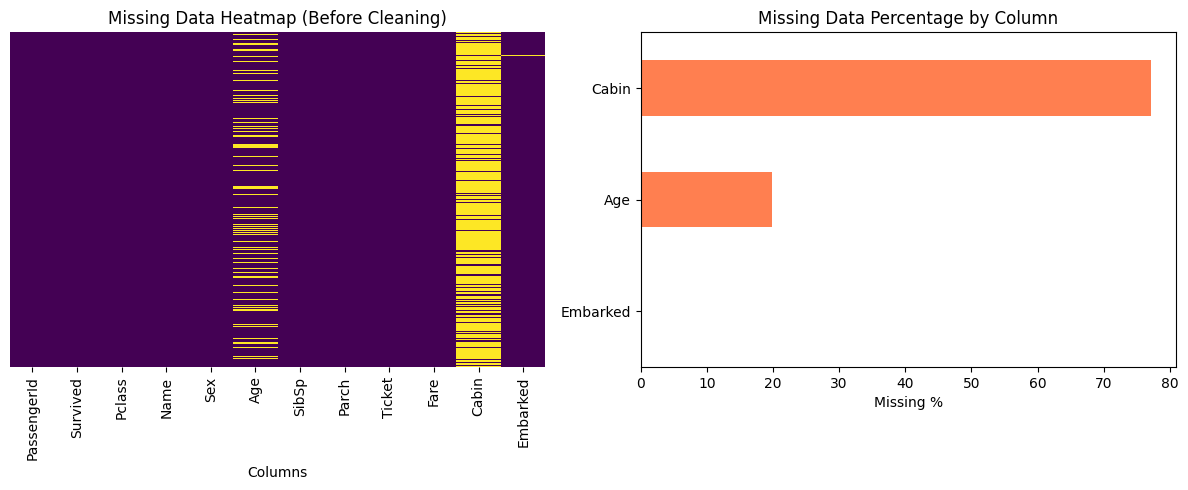

📊 Missing data chart saved!


In [7]:
# Missing value heatmap
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Before Cleaning)')
plt.xlabel('Columns')

plt.subplot(1,2,2)
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0]
missing_pct.sort_values().plot(kind='barh', color='coral')
plt.title('Missing Data Percentage by Column')
plt.xlabel('Missing %')

plt.tight_layout()
plt.savefig('missing_data_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Missing data chart saved!")

In [9]:
#Handling Missing Values
#  Age
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

#  Embarked
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
#Cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'].fillna('Unknown', inplace=True)
df.drop(columns=['Cabin'], inplace=True)
#Fare
print(f"Fare missing: {df['Fare'].isnull().sum()}")
df['Fare'].fillna(df['Fare'].median(), inplace=True)
#verify
print("\n✅ Missing values after treatment:")
print(df.isnull().sum())

Fare missing: 0

✅ Missing values after treatment:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64


In [10]:
# --- Duplicates ---
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after:  {df.duplicated().sum()}")

# --- Fix data types ---
# Categorical columns
for col in ['Survived', 'Pclass', 'Sex', 'Embarked', 'Deck']:
    df[col] = df[col].astype('category')

# Integer where appropriate
df['Age'] = df['Age'].astype(int)
df['SibSp'] = df['SibSp'].astype(int)
df['Parch'] = df['Parch'].astype(int)

print("\n✅ Updated data types:")
print(df.dtypes)

# --- Create useful derived features (bonus!) ---
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("\n Bonus features added: FamilySize, IsAlone, Title")

Duplicates before: 0
Duplicates after:  0

✅ Updated data types:
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age               int64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
Deck           category
dtype: object

 Bonus features added: FamilySize, IsAlone, Title


In [11]:
# Rename for clarity
df.rename(columns={
    'PassengerId': 'passenger_id',
    'Survived':    'survived',
    'Pclass':      'ticket_class',
    'Name':        'full_name',
    'Sex':         'gender',
    'Age':         'age',
    'SibSp':       'siblings_spouses',
    'Parch':       'parents_children',
    'Ticket':      'ticket_number',
    'Fare':        'fare_paid',
    'Embarked':    'port_of_embarkation',
    'Deck':        'deck',
    'FamilySize':  'family_size',
    'IsAlone':     'is_alone',
    'Title':       'title'
}, inplace=True)

# Drop columns not needed for analysis
df.drop(columns=['ticket_number', 'full_name'], inplace=True)

# Final shape and preview
print(f"✅ Final dataset shape: {df.shape}")
print("\nColumn list:", df.columns.tolist())
df.head()

✅ Final dataset shape: (891, 13)

Column list: ['passenger_id', 'survived', 'ticket_class', 'gender', 'age', 'siblings_spouses', 'parents_children', 'fare_paid', 'port_of_embarkation', 'deck', 'family_size', 'is_alone', 'title']


,passenger_id,survived,ticket_class,gender,age,siblings_spouses,parents_children,fare_paid,port_of_embarkation,deck,family_size,is_alone,title
0,1,0,3,male,22,1,0,7.2500,S,Unknown,2,0,Mr
1,2,1,1,female,38,1,0,71.2833,C,C,2,0,Mrs
2,3,1,3,female,26,0,0,7.9250,S,Unknown,1,1,Miss
3,4,1,1,female,35,1,0,53.1000,S,C,2,0,Mrs
4,5,0,3,male,35,0,0,8.0500,S,Unknown,1,1,Mr


=== FINAL QUALITY CHECK ===
Total missing values: 0
Total rows: 891
Total columns: 13

✅ Cleaning Summary:
- Age: imputed with median grouped by ticket class
- Embarked: 2 values filled with mode (S)
- Cabin: extracted Deck letter, dropped rest
- Added: FamilySize, IsAlone, Title features
- Renamed all columns to snake_case
- Removed non-informative columns (ticket number, name)


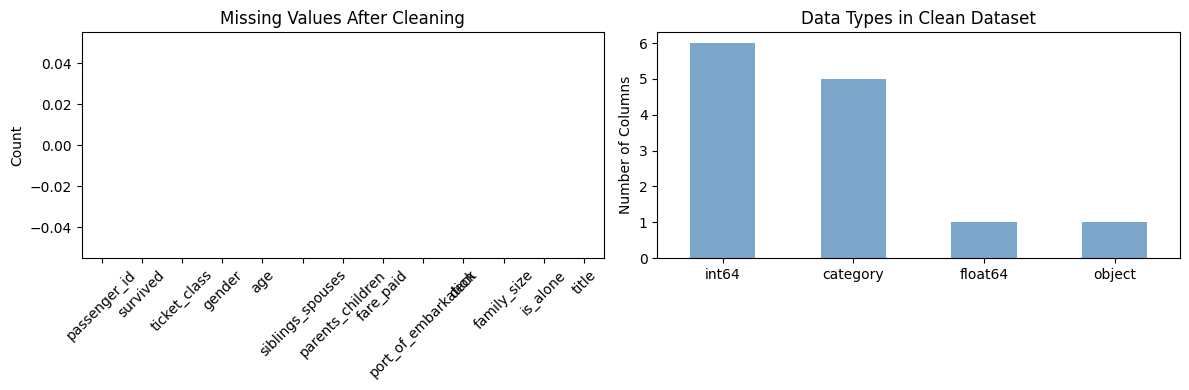


📁 Saved: titanic_cleaned.csv

Final dataset preview:


,passenger_id,survived,ticket_class,gender,age,siblings_spouses,parents_children,fare_paid,port_of_embarkation,deck,family_size,is_alone,title
0,1,0,3,male,22,1,0,7.2500,S,Unknown,2,0,Mr
1,2,1,1,female,38,1,0,71.2833,C,C,2,0,Mrs
2,3,1,3,female,26,0,0,7.9250,S,Unknown,1,1,Miss
3,4,1,1,female,35,1,0,53.1000,S,C,2,0,Mrs
4,5,0,3,male,35,0,0,8.0500,S,Unknown,1,1,Mr


In [12]:
# Final missing value check
print("=== FINAL QUALITY CHECK ===")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print(f"\n✅ Cleaning Summary:")
print("- Age: imputed with median grouped by ticket class")
print("- Embarked: 2 values filled with mode (S)")
print("- Cabin: extracted Deck letter, dropped rest")
print("- Added: FamilySize, IsAlone, Title features")
print("- Renamed all columns to snake_case")
print("- Removed non-informative columns (ticket number, name)")

# Visual before vs after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: final missing values (should all be 0)
df.isnull().sum().plot(kind='bar', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Missing Values After Cleaning')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Right: final data types
dtype_counts = df.dtypes.astype(str).value_counts()
dtype_counts.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Data Types in Clean Dataset')
axes[1].set_ylabel('Number of Columns')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('cleaning_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Save clean dataset
df.to_csv('titanic_cleaned.csv', index=False)
print("\n📁 Saved: titanic_cleaned.csv")
print(f"\nFinal dataset preview:")
df.head()